# Fase 5 — Evaluación comparativa unificada
**Proyecto:** FruitVision — Clasificación de Calidad de Frutas

---
Compara en igualdad de condiciones (mismo test, split **sin fuga**) los modelos
ya entrenados: **Baseline, Random Forest, XGBoost, CNN**. Incluye tabla,
matrices de confusión, **análisis de errores** y un **desglose por fuente**
(Kaggle vs propio) que mide la generalización al dataset recolectado por el grupo.

Este notebook **NO entrena**: carga los modelos guardados y los evalúa.

In [1]:
import sys, pathlib, os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, joblib, cv2, collections
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
import tensorflow as tf
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from src.config import QUALITY_CLASSES, CNN_IMG_SIZE, MODELS_DIR, FIGURES_DIR
from src.data.preprocessing import load_manifest
from src.features.extract import build_feature_matrix
from src.data.paths import load_image_rgb

I0000 00:00:1780725158.251206  390765 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1780725159.597401  390765 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. Cargar modelos y datos de prueba

In [2]:
Xtr, ytr = build_feature_matrix(load_manifest('train'), 'train')
te = load_manifest('test')
Xte, yte = build_feature_matrix(te, 'test')
def load_imgs(manifest, size=CNN_IMG_SIZE):
    X = np.zeros((len(manifest), *size, 3), np.float32)
    for i, p in enumerate(manifest['abs_path']):
        img = load_image_rgb(p)
        if img is not None: X[i] = cv2.resize(img, size).astype(np.float32) / 255.0
    return X
Xte_img = load_imgs(te)
rf = joblib.load(MODELS_DIR/"random_forest.pkl"); xgbm = joblib.load(MODELS_DIR/"xgboost.pkl")
cnn = tf.keras.models.load_model(MODELS_DIR/"cnn_quality.keras")
dummy = DummyClassifier(strategy='most_frequent').fit(Xtr, ytr)
print("Test:", len(te), "| por fuente:", te['source'].value_counts().to_dict())

E0000 00:00:1780725164.702760  390765 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


Test: 1082 | por fuente: {'kaggle': 651, 'propio': 431}


## 2. Predicciones

In [3]:
preds = {'Baseline': dummy.predict(Xte), 'Random Forest': rf.predict(Xte),
         'XGBoost': xgbm.predict(Xte), 'CNN': cnn.predict(Xte_img, verbose=0).argmax(1)}

## 3. Tabla comparativa

               accuracy  f1_macro
modelo                           
Baseline          0.347     0.172
Random Forest     0.891     0.892
XGBoost           0.942     0.942
CNN               0.921     0.922


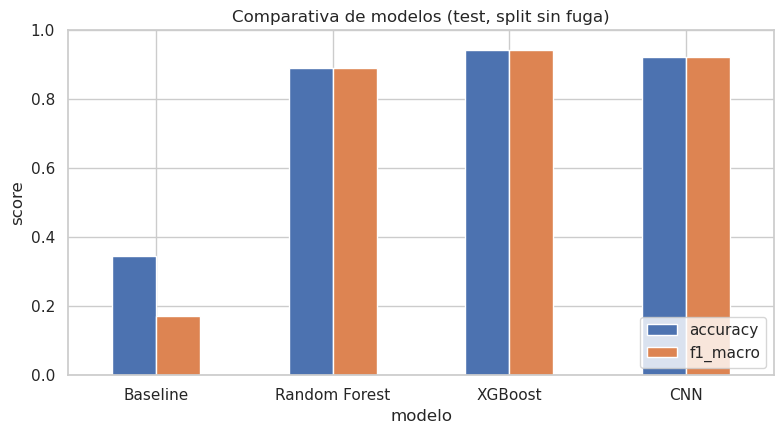

In [4]:
results = pd.DataFrame([{'modelo':n, 'accuracy':accuracy_score(yte,p),
    'f1_macro':f1_score(yte,p,average='macro')} for n,p in preds.items()]).set_index('modelo')
print(results.round(3))
ax = results.plot.bar(figsize=(8,4.5), rot=0); ax.set_ylim(0,1); ax.legend(loc='lower right')
ax.set_title("Comparativa de modelos (test, split sin fuga)"); ax.set_ylabel("score")
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase5_comparativa.pdf", bbox_inches="tight"); plt.show()

## 4. Métricas por clase y matrices de confusión

In [5]:
for name in ['Random Forest','XGBoost','CNN']:
    print(f"=== {name} ==="); print(classification_report(yte, preds[name], target_names=QUALITY_CLASSES, digits=3))

=== Random Forest ===
              precision    recall  f1-score   support

     Premium      0.947     0.840     0.891       363
    Estándar      0.929     0.881     0.904       344
    Descarte      0.820     0.949     0.880       375

    accuracy                          0.891      1082
   macro avg      0.899     0.890     0.892      1082
weighted avg      0.898     0.891     0.891      1082

=== XGBoost ===
              precision    recall  f1-score   support

     Premium      0.965     0.909     0.936       363
    Estándar      0.967     0.951     0.959       344
    Descarte      0.900     0.965     0.932       375

    accuracy                          0.942      1082
   macro avg      0.944     0.942     0.942      1082
weighted avg      0.943     0.942     0.942      1082

=== CNN ===
              precision    recall  f1-score   support

     Premium      0.906     0.961     0.933       363
    Estándar      0.939     0.933     0.936       344
    Descarte      0.921  

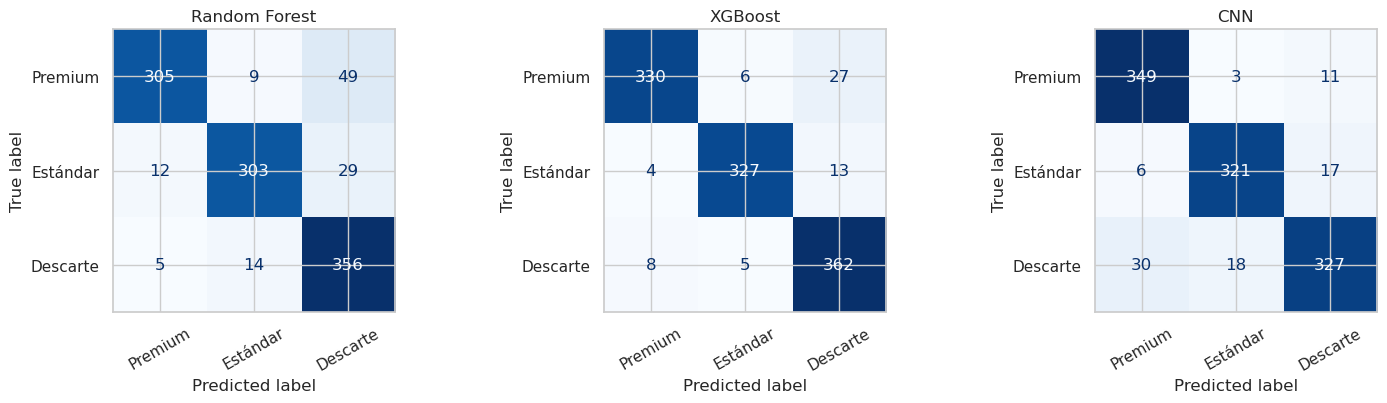

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for a, name in zip(ax, ['Random Forest','XGBoost','CNN']):
    ConfusionMatrixDisplay(confusion_matrix(yte, preds[name]), display_labels=QUALITY_CLASSES).plot(ax=a, cmap='Blues', colorbar=False)
    a.set_title(name); a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase5_confusion.pdf", bbox_inches="tight"); plt.show()

## 5. Análisis de errores (mejor modelo)

Mejor modelo: XGBoost | errores: 63/1082

Confusiones (real -> predicho):
  Premium   -> Descarte : 27
  Estándar  -> Descarte : 13
  Descarte  -> Premium  : 8
  Premium   -> Estándar : 6
  Descarte  -> Estándar : 5


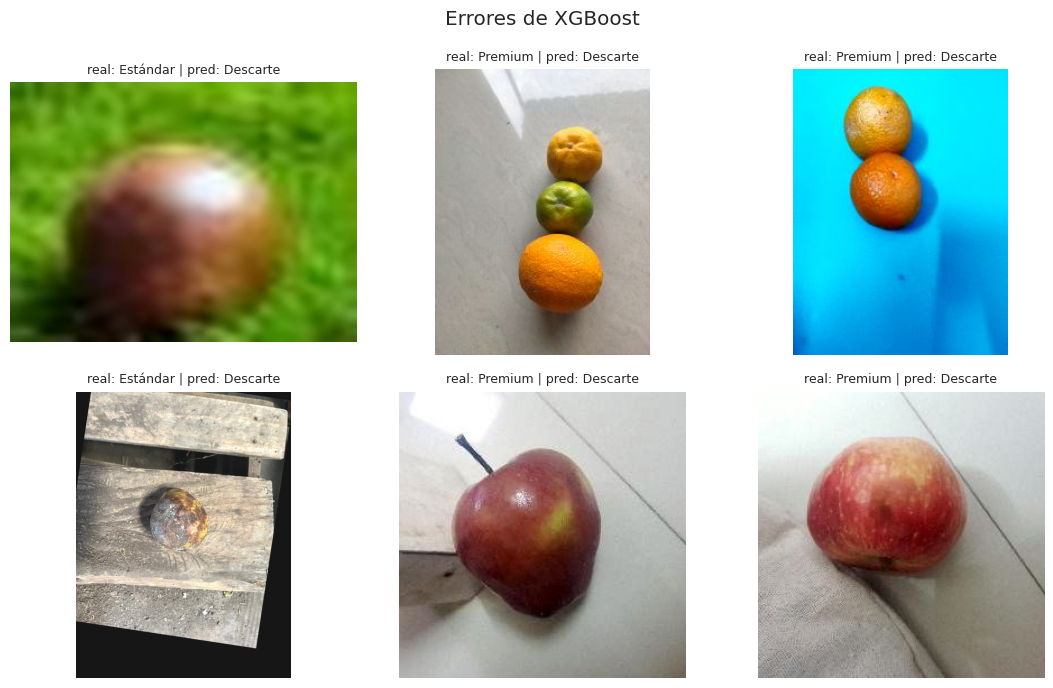

In [7]:
best_name = results.drop('Baseline')['f1_macro'].idxmax(); best = preds[best_name]
wrong = np.where(best != yte)[0]
print(f"Mejor modelo: {best_name} | errores: {len(wrong)}/{len(yte)}")
pairs = collections.Counter((QUALITY_CLASSES[yte[i]], QUALITY_CLASSES[best[i]]) for i in wrong)
print("\nConfusiones (real -> predicho):")
for (a,b),c in pairs.most_common(5): print(f"  {a:9s} -> {b:9s}: {c}")
sample = wrong[:6]
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, i in zip(axes.flatten(), sample):
    ax.imshow(load_image_rgb(te.iloc[i]['abs_path'])); ax.axis('off')
    ax.set_title(f"real: {QUALITY_CLASSES[yte[i]]} | pred: {QUALITY_CLASSES[best[i]]}", fontsize=9)
for ax in axes.flatten()[len(sample):]: ax.axis('off')
plt.suptitle(f"Errores de {best_name}"); plt.tight_layout()
plt.savefig(FIGURES_DIR/"fase5_errores.pdf", bbox_inches="tight"); plt.show()

## 6. Desglose por fuente: Kaggle vs Dataset propio
Medimos el desempeño por separado en imágenes de Kaggle y en las recolectadas por
el grupo. Una caída en el dataset propio indica *domain shift* (otra cámara/luz/
fondo) — la prueba de generalización real. La clase **Estándar** solo aparece en
las imágenes propias (es la fuente de esa clase).

In [8]:
rows = []
for src in ['kaggle','propio']:
    mask = (te['source']==src).values
    if mask.sum()==0: continue
    for name,p in preds.items():
        if name=='Baseline': continue
        rows.append({'fuente':src, 'modelo':name, 'n':int(mask.sum()),
                     'accuracy':accuracy_score(yte[mask], p[mask]),
                     'f1_macro':f1_score(yte[mask], p[mask], average='macro')})
by_source = pd.DataFrame(rows).set_index(['fuente','modelo'])
print(by_source.round(3))

                        n  accuracy  f1_macro
fuente modelo                                
kaggle Random Forest  651     0.896     0.604
       XGBoost        651     0.939     0.629
       CNN            651     0.928     0.622
propio Random Forest  431     0.884     0.798
       XGBoost        431     0.947     0.891
       CNN            431     0.912     0.814


## 7. Resumen de la Fase 5
- Comparación justa (mismo test, split **sin fuga**).
- Tabla, matrices de confusión y **análisis de errores**.
- **Desglose por fuente** (Kaggle vs propio) → evidencia de generalización.
- Recordatorio: la salida de **tamaño** se evalúa aparte (medición por segmentación).